# BDOT10k Warszawa — otoczenie lokalu jako zestaw cech ML

> **Wynik wykonania (20.09.2026):** 73 pliki, 535 801 obiektów i 34 grupy tematyczne. Utworzono **78 cech modelowych oraz 10 pól kontroli jakości** dla 229 727 rekordów lokali. Końcowy przebieg obliczeń trwał około 2 minut. Wszystkie komórki wykonano, a kontrole zakończyły się poprawnie.

**Cel:** rozpoznać całą lokalną paczkę GML, wybrać interpretowalne wskaźniki otoczenia i obliczyć je dla wszystkich rekordów `warszawa_lokale.csv`. Hipotezy o przydatności cech wymagają późniejszej walidacji modelu — ten notebook nie dowodzi poprawy predykcji.

Notebook zawiera cały proces: **inwentaryzacja → interpretacja → kontrola geometrii → wybór obiektów → Haversine → walidacja → eksport**. Nie zmienia plików wejściowych ani nie odrzuca transakcji. Wspólne współrzędne oblicza raz, a potem dołącza wynik do oryginalnej kolejności wierszy.

### Uruchomienie

W katalogu projektu: `python3 -m venv .venv`, następnie aktywuj środowisko i wykonaj `python -m pip install -r requirements.txt`. Otwórz notebook w edytorze obsługującym Jupyter, wybierz interpreter `.venv` i **Run All**. Python ≥3.11. Pierwsze wykonanie czyta ok. 755 MB GML; obliczenia i eksport mogą potrwać kilka minut. Pliki w `dane/pochodne_bdot10k/` są odtwarzalne i zostaną zastąpione przy kolejnym wykonaniu.

### Źródła i zakres

- Paczka **Powiat Warszawa – GML** z Geoportalu, dostarczona w `dane/BDOT10k/`. To bezpośrednie źródło wszystkich wartości, liczebności i filtrów poniżej.
- [GUGiK: opis BDOT10k](https://www.geoportal.gov.pl/pl/dane/baza-danych-obiektow-topograficznych-bdot10k/) — baza geometrii i charakterystyk obiektów topograficznych, o szczegółowości odpowiadającej mapie 1:10 000.
- [Vademecum BDOT10k](https://wodgik.lubuskie.pl/uploads/VADEMECUM_UZYTKOWNIKA_BDOT10k_2024.pdf) — pomoc w interpretacji klas; faktyczne pola i wartości zawsze odczytujemy z paczki.
- [scikit-learn: Haversine](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.haversine_distances.html), [BallTree](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.BallTree.html), [pyproj: kolejność osi](https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6) — dokumentacja obliczeń.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime, timezone
import hashlib, json, math, platform, time, importlib.metadata
import numpy as np
import pandas as pd
from lxml import etree
import shapely
from shapely.geometry import Point, LineString, Polygon, MultiLineString, MultiPolygon, GeometryCollection
from shapely.ops import transform as geometry_transform
from shapely import STRtree
from pyproj import CRS, Transformer
from sklearn.neighbors import BallTree
from IPython.display import display, Markdown
import matplotlib.pyplot as plt

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'dane/BDOT10k').is_dir()), None)
assert ROOT is not None, 'Uruchom notebook w katalogu repozytorium.'
GML_DIR = ROOT / 'dane/BDOT10k'
INPUT = ROOT / 'dane/warszawa_lokale.csv'
OUT = ROOT / 'dane/pochodne_bdot10k'
OUT.mkdir(parents=True, exist_ok=True)
EARTH_R_M = 6_371_008.8
BOUNDARY_STEP_M = 10.0  # maksymalny docelowy odstęp próbek linii/granic
BATCH = 2048
STARTED = time.perf_counter()
SOURCES = sorted(GML_DIR.glob('*.xml')) + sorted(GML_DIR.glob('*.gml'))
assert SOURCES, 'Brak plików GML/XML.'
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_rows', 90)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
versions = {p: importlib.metadata.version(p) for p in ['numpy','pandas','shapely','pyproj','scikit-learn','lxml','nbformat','nbclient','ipykernel','matplotlib']}
print(f'Pliki: {len(SOURCES)}; rozmiar: {sum(p.stat().st_size for p in SOURCES)/1024**2:.1f} MiB')
print('Python:', platform.python_version(), '| wersje:', versions)

Pliki: 73; rozmiar: 754.9 MiB
Python: 3.11.3 | wersje: {'numpy': '2.4.6', 'pandas': '3.0.6', 'shapely': '2.1.2', 'pyproj': '3.7.2', 'scikit-learn': '1.9.1', 'lxml': '6.1.3', 'nbformat': '5.11.1', 'nbclient': '0.11.0', 'ipykernel': '7.3.0', 'matplotlib': '3.11.2'}


## 1. Co opisuje paczka?

Inwentaryzacja obejmuje **każdy plik**, także pusty i niewykorzystywany do cech. Sufiksy `A`, `L`, `P` oznaczają reprezentację powierzchniową, liniową i punktową. Ta sama rzecz może występować w dwóch reprezentacjach — np. kompleks stacji jako punkt i obszar. Nie sumujemy takich reprezentacji.

Tabela poniżej łączy odczytane liczebności, geometrię, wersje i pola z oceną zastosowania. Pola wielokrotne (szczególnie funkcje budynku) zachowujemy jako listy. Zliczenia wartości atrybutów oznaczają liczbę **obiektów mających daną wartość**, nie liczbę jej powtórzeń w XML.

In [2]:
# Krótkie opisy dotyczą zawartości klas, nie gwarancji kompletności rejestru usług.
CLASS_NAMES = {
 'ADJA':'Granice jednostek administracyjnych','ADMS':'Miejscowości i części miasta',
 'BUBD':'Budynki: funkcje, kondygnacje, EGiB','BUHD':'Budowle hydrotechniczne',
 'BUIB':'Inne budowle (m.in. perony)','BUIN':'Mosty, wiadukty, tunele, kładki',
 'BUIT':'Urządzenia techniczne','BUSP':'Place zabaw i budowle sportowe',
 'BUTR':'Urządzenia transportowe','BUUO':'Umocnienia i ściany oporowe',
 'BUWT':'Wysokie budowle techniczne','BUZM':'Nasypy, wały, wykopy','BUZT':'Zbiorniki i osadniki',
 'KUHO':'Kompleksy hotelarskie','KUHU':'Targowiska','KUKO':'Kompleksy komunikacyjne',
 'KUMN':'Kompleksy mieszkaniowe','KUOS':'Kompleksy oświatowe','KUOZ':'Kompleksy zdrowia i opieki',
 'KUPG':'Kompleksy przemysłowo-gospodarcze','KUPW':'Poligony wojskowe',
 'KUSC':'Kompleksy sakralne i cmentarze','KUSK':'Parki i kompleksy rekreacyjne',
 'KUZA':'Kompleksy historyczne','OIKM':'Obiekty komunikacyjne (typ zależy od geometrii)',
 'OIMK':'Mokradła','OIOR':'Obiekty orientacyjne','OIPR':'Obiekty przyrodnicze',
 'OISZ':'Szuwary','PTGN':'Grunty nieużytkowane','PTKM':'Tereny komunikacyjne',
 'PTLZ':'Lasy i zadrzewienia','PTNZ':'Inne tereny niezabudowane','PTPL':'Place',
 'PTRK':'Roślinność krzewiasta','PTSO':'Składowiska odpadów','PTTR':'Trawy i uprawy rolne',
 'PTUT':'Uprawy trwałe i ogródki działkowe','PTWP':'Wody powierzchniowe',
 'PTWZ':'Wyrobiska i zwałowiska','PTZB':'Obszary zabudowy',
 'RTLW':'Poziomice','RTPW':'Punkty wysokościowe','SKDR':'Osie dróg','SKJZ':'Osie jezdni',
 'SKPP':'Przeprawy','SKRP':'Ciągi piesze i rowerowe','SKRW':'Ronda i węzły',
 'SKTR':'Tory kolejowe, tramwajowe i metra','SULN':'Linie elektroenergetyczne',
 'SUPR':'Przewody rurowe','SWKN':'Kanały','SWRM':'Rowy melioracyjne','SWRS':'Rzeki i strumienie',
 'TCON':'Obszary Natura 2000','TCPK':'Parki krajobrazowe','TCPN':'Parki narodowe','TCRZ':'Rezerwaty',
}
# Geometrie potrzebne w bieżącym zestawie; pozostałe pliki nadal podlegają inwentaryzacji.
LOAD = {'OT_'+c for c in [
 'ADJA_A','BUBD_A','BUSP_A','KUKO_A','KUOS_A','KUOZ_A','KUPG_A','KUSC_A','KUSK_A','KUZA_A',
 'OIKM_P','OIPR_P','PTLZ_A','PTTR_A','PTWP_A','PTUT_A','PTZB_A','SKDR_L','SKRP_L','SKTR_L','SULN_L','TCRZ_A']}
RATIONALE = {
 'ADJA':'Dzielnica i kontrola granic paczki.', 'BUBD':'Usługi oraz intensywność i typ zabudowy.',
 'BUSP':'Dostęp do rekreacji; dostępność publiczna nieznana.', 'KUKO':'Lotniska i stacje paliw; nie łączyć A/P.',
 'KUOS':'Szkoły i uczelnie; kampus nie jest liczbą placówek.', 'KUOZ':'Szpitale; kompleks nie jest liczbą lekarzy.',
 'KUPG':'Bliskość działalności gospodarczej i potencjalnych uciążliwości.',
 'KUSC':'Cmentarze jako cecha otoczenia; bez wykorzystywania wyznania.',
 'KUSK':'Parki i skwery jako potencjalny walor lokalizacji.', 'KUZA':'Otoczenie historyczne i turystyczne.',
 'OIKM':'Dostępność transportu; punkty wejść i przystanków.',
 'OIPR':'Punkty drzew/grup drzew, a nie pełny spis drzew.',
 'PTLZ':'Zieleń wysoka.', 'PTTR':'Zieleń niska; oddzielić grunty orne.',
 'PTWP':'Woda jako walor otoczenia; nie jest mapą zagrożenia powodziowego.',
 'PTUT':'Ogródki działkowe jako specyficzny typ zieleni.', 'PTZB':'Charakter otoczenia i pokrycie zabudową.',
 'SKDR':'Bliskość głównych dróg; przybliżenie ekspozycji, nie pomiar hałasu.',
 'SKRP':'Dostęp do tras rowerowych.', 'SKTR':'Rozdzielić kolej/tramwaj/metro i położenie pod ziemią.',
 'SULN':'Sąsiedztwo linii wysokiego napięcia.', 'TCRZ':'Bliskość chronionej przyrody.',
}
DEFER = {
 'SKJZ':'Pokrywa się z drogami; w tej iteracji stosujemy SKDR.',
 'RTLW':'Do wysokości/nachylenia lepszy zweryfikowany NMT; nie interpolujemy samych poziomic.',
 'RTPW':'Rzadka próbka wysokości nie określa wysokości każdego lokalu.',
 'ADMS':'Części miasta mogą się nakładać; w tej iteracji używamy dzielnic ADJA.',
 'OISZ':'Możliwe uzupełnienie zieleni/mokradeł; brak pomiaru ryzyka powodzi.',
 'OIMK':'Możliwa cecha mokradeł; nie zastępuje map zagrożenia powodziowego.',
 'PTSO':'Możliwe uzupełnienie odpadów; obecnie używamy kompleksów KUPG.',
 'KUMN':'Nazwy i granice osiedli; typ zabudowy bierzemy z BUBD/PTZB.',
}
GML = '{http://www.opengis.net/gml/3.2}'
NS = {'gml': GML[1:-1]}

def local(tag): return etree.QName(tag).localname

def feature_members(path):
    # Strumieniowo: nie przechowujemy całego drzewa 755 MB w pamięci.
    for _, member in etree.iterparse(str(path), events=('end',), tag=GML+'featureMember',
                                    huge_tree=True, resolve_entities=False, no_network=True):
        if len(member) != 1:
            raise ValueError(f'{path.name}: nieoczekiwana struktura featureMember')
        yield member[0]
        member.clear()
        while member.getprevious() is not None:
            del member.getparent()[0]

def read_attributes(obj):
    result = defaultdict(list)
    for node in obj:
        if local(node.tag) == 'geometria': continue
        value = ' '.join(''.join(node.itertext()).split())
        if value: result[local(node.tag)].append(value)
    return {k: v[0] if len(v)==1 else v for k,v in result.items()}

def values(v): return v if isinstance(v, list) else [v]

def parse_geometry(node):
    """Dokładnie obsługiwane typy tej paczki; nieznana konstrukcja kończy wykonanie."""
    kind = local(node.tag)
    if node.get('srsDimension', '2') != '2': raise ValueError('Oczekiwana geometria 2D')
    def coords(parent):
        pos = parent.find('.//'+GML+'posList')
        if pos is None: pos = parent.find('.//'+GML+'pos')
        if pos is None: raise ValueError('Brak pos/posList')
        arr = np.fromstring(pos.text or '', sep=' ')
        if len(arr)%2 or len(arr)<2 or not np.isfinite(arr).all(): raise ValueError('Błędne współrzędne')
        return arr.reshape(-1,2)
    if kind == 'Point': return Point(coords(node)[0])
    if kind == 'LineString': return LineString(coords(node))
    if kind == 'Curve':
        segments = node.find(GML+'segments')
        if segments is None or not len(segments): raise ValueError('Brak segmentów')
        if any(local(s.tag)!='LineStringSegment' for s in segments): raise ValueError('Nieobsługiwany łuk')
        parts = [LineString(coords(s)) for s in segments]
        return parts[0] if len(parts)==1 else MultiLineString(parts)
    if kind == 'Polygon':
        exterior = node.find(GML+'exterior')
        if exterior is None: raise ValueError('Brak pierścienia zewnętrznego')
        holes = [coords(r) for r in node.findall(GML+'interior')]
        return Polygon(coords(exterior), holes)
    raise ValueError(f'Nieobsługiwany typ GML: {kind}')

def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024), b''): h.update(block)
    return h.hexdigest()

layers, inventory_rows, attribute_rows, version_rows = {}, [], [], []
input_manifest=[]
for j,path in enumerate(SOURCES):
    layer=path.stem.split('__')[-1]
    assert layer not in layers, f'Powtórzony plik warstwy: {layer}'
    n=0; geoms=Counter(); crs=Counter(); fields=defaultdict(Counter); present=Counter()
    rows=[]; ids=set(); duplicates=0; repairs=0; versions_seen=Counter()
    for obj in feature_members(path):
        n+=1
        attrs=read_attributes(obj)
        oid=attrs.get('lokalnyId',obj.get(GML+'id'))
        duplicates+=int(oid in ids); ids.add(oid)
        for key,value in attrs.items():
            present[key]+=1
            fields[key].update(set(values(value)))
        versions_seen.update(values(attrs.get('wersja','brak')))
        node=obj.find('./{*}geometria')
        if node is None or len(node)!=1: raise ValueError(f'{layer}: brak/jednoznaczność geometrii')
        gnode=node[0]
        geoms[local(gnode.tag)]+=1; crs[gnode.get('srsName','brak')]+=1
        if layer in LOAD:
            g=parse_geometry(gnode)
            if not g.is_valid:
                g=shapely.make_valid(g); repairs+=1
            if g.is_empty or not g.is_valid: raise ValueError(f'{layer}: geometria niepoprawna po naprawie')
            # Nie gubimy części po naprawie poligonu.
            if local(gnode.tag)=='Polygon' and g.geom_type not in ['Polygon','MultiPolygon']:
                raise ValueError(f'{layer}: naprawa zmieniła wymiar obiektu {oid}')
            rows.append({**attrs,'_id':oid,'geometry':g})
    if duplicates: raise ValueError(f'{layer}: {duplicates} powtórzeń lokalnyId — ustal wersjonowanie przed agregacją')
    base=layer.split('_')[1]
    assert base in CLASS_NAMES, f'Opisz nową klasę: {base}'
    if layer in LOAD: layers[layer]=pd.DataFrame(rows)
    inventory_rows.append({'warstwa':layer,'opis':CLASS_NAMES[base],'obiekty':n,
        'geometria':json.dumps(dict(geoms),ensure_ascii=False),'CRS':json.dumps(dict(crs)),
        'uzyta':layer in LOAD,'ocena':RATIONALE.get(base,DEFER.get(base,'Możliwe rozwinięcie; obecnie mniejszy priorytet lub niejednoznaczna interpretacja.')),
        'naprawione_geometrie':repairs if layer in LOAD else pd.NA,
        'liczba_atrybutow':len(fields),'plik':path.name})
    for key,counter in fields.items():
        attribute_rows.append({'warstwa':layer,'atrybut':key,'obiekty_z_wartoscia':present[key],
            'braki':n-present[key],'unikalne_wartosci':len(counter),
            'najczestsze':json.dumps(counter.most_common(12),ensure_ascii=False)})
    for version,count in versions_seen.items(): version_rows.append({'warstwa':layer,'wersja':version,'obiekty':count})
    input_manifest.append({'plik':str(path.relative_to(ROOT)),'bytes':path.stat().st_size,'sha256':sha256(path)})
    if (j+1)%10==0 or j+1==len(SOURCES): print(f'Przeczytano {j+1}/{len(SOURCES)} plików')

inventory=pd.DataFrame(inventory_rows)
attributes=pd.DataFrame(attribute_rows)
source_versions=pd.DataFrame(version_rows)
assert LOAD <= set(layers), 'Brak wymaganej warstwy'
display(inventory[['warstwa','opis','obiekty','geometria','uzyta','ocena']])
print('Łącznie rekordów obiektów:', inventory.obiekty.sum())
display(source_versions.groupby('wersja',as_index=False).obiekty.sum())
display(inventory.loc[inventory.obiekty.eq(0),['warstwa','opis']])

Przeczytano 10/73 plików


Przeczytano 20/73 plików
Przeczytano 30/73 plików


Przeczytano 40/73 plików


Przeczytano 50/73 plików


Przeczytano 60/73 plików


Przeczytano 70/73 plików
Przeczytano 73/73 plików


,warstwa,opis,obiekty,geometria,uzyta,ocena
0,OT_ADJA_A,Granice jednostek administracyjnych,22,"{""Polygon"": 22}",True,Dzielnica i kontrola granic paczki.
1,OT_ADMS_A,Miejscowości i części miasta,199,"{""Polygon"": 199}",False,Części miasta mogą się nakładać; w tej iteracji używamy dzielnic ADJA.
2,OT_ADMS_P,Miejscowości i części miasta,199,"{""Point"": 199}",False,Części miasta mogą się nakładać; w tej iteracji używamy dzielnic ADJA.
3,OT_BUBD_A,"Budynki: funkcje, kondygnacje, EGiB",167103,"{""Polygon"": 167103}",True,Usługi oraz intensywność i typ zabudowy.
4,OT_BUHD_A,Budowle hydrotechniczne,2,"{""Polygon"": 2}",False,Możliwe rozwinięcie; obecnie mniejszy priorytet lub niejednoznaczna interpretacja.
5,OT_BUHD_L,Budowle hydrotechniczne,25,"{""Curve"": 25}",False,Możliwe rozwinięcie; obecnie mniejszy priorytet lub niejednoznaczna interpretacja.
6,OT_BUIB_A,Inne budowle (m.in. perony),106,"{""Polygon"": 106}",False,Możliwe rozwinięcie; obecnie mniejszy priorytet lub niejednoznaczna interpretacja.
7,OT_BUIB_L,Inne budowle (m.in. perony),31,"{""Curve"": 31}",False,Możliwe rozwinięcie; obecnie mniejszy priorytet lub niejednoznaczna interpretacja.
8,OT_BUIN_L,"Mosty, wiadukty, tunele, kładki",1535,"{""Curve"": 1535}",False,Możliwe rozwinięcie; obecnie mniejszy priorytet lub niejednoznaczna interpretacja.
9,OT_BUIT_A,Urządzenia techniczne,32,"{""Polygon"": 32}",False,Możliwe rozwinięcie; obecnie mniejszy priorytet lub niejednoznaczna interpretacja.


Łącznie rekordów obiektów: 535801


,wersja,obiekty
0,2023-12-31T12:00:00,122712
1,2024-10-22T12:00:00,28372
2,2025-06-01T12:00:00,384717


,warstwa,opis
14,OT_BUTR_P,Urządzenia transportowe
16,OT_BUWT_A,Wysokie budowle techniczne
71,OT_TCPN_A,Parki narodowe


## 2. Układ współrzędnych i jakość geometrii

**Pułapka osi:** definicja EPSG:2180 podaje osie northing/easting, ale badana paczka zapisuje pary odpowiadające **easting/northing (E,N)**. Samo użycie domyślnego transformatora może umieścić Warszawę w innym miejscu Polski. Testujemy obie interpretacje na próbkach każdej używanej warstwy, wybieramy jednoznacznie pasującą do regionu Warszawy i sprawdzamy cały zakres punktów reprezentatywnych. Przeliczenie stosuje `always_xy=True`; BallTree dostaje dopiero **[latitude, longitude] w radianach**.

Do relacji „punkt leży w poligonie” używamy Shapely. Do odległości i promieni używamy wyłącznie metryki Haversine'a, po transformacji do WGS84. Nie stosujemy odległości euklidesowej w EPSG:2180 ani buforów w stopniach.

In [3]:
TO_WGS84=Transformer.from_crs(2180,4326,always_xy=True)
TO_2180=Transformer.from_crs(4326,2180,always_xy=True)

def xy_to_latlon(xy):
    xy=np.asarray(xy,dtype=float)
    lon,lat=TO_WGS84.transform(xy[:,0],xy[:,1])
    return np.column_stack([lat,lon])

def plausible(ll):
    # Szeroki region kontrolny, NIE granica administracyjna ani filtr transakcji.
    return (ll[:,0]>51.5)&(ll[:,0]<53.0)&(ll[:,1]>20.0)&(ll[:,1]<22.0)

axis_rows=[]
for layer,df in layers.items():
    assert not df.empty, f'Pusta warstwa wymagana do obliczeń: {layer}'
    assert set(json.loads(inventory.set_index('warstwa').loc[layer,'CRS']))=={'EPSG:2180'}
    geom=df.geometry.to_numpy()
    rp=shapely.point_on_surface(geom)
    xy=shapely.get_coordinates(rp)
    sample=xy[np.linspace(0,len(xy)-1,min(100,len(xy)),dtype=int)]
    direct=float(plausible(xy_to_latlon(sample)).mean())
    swapped=float(plausible(xy_to_latlon(sample[:,::-1])).mean())
    if direct>0.99 and swapped<0.01: axis='E,N'
    elif swapped>0.99 and direct<0.01:
        axis='N,E'; geom=np.array([geometry_transform(lambda x,y:(y,x),g) for g in geom],dtype=object)
        df['geometry']=geom; xy=shapely.get_coordinates(shapely.point_on_surface(geom))
    else: raise ValueError(f'{layer}: niejednoznaczne osie: {direct=}, {swapped=}')
    ll=xy_to_latlon(xy)
    assert plausible(ll).all(), f'{layer}: obiekt poza regionem kontrolnym'
    df['_lat']=ll[:,0]; df['_lon']=ll[:,1]
    axis_rows.append({'warstwa':layer,'osie_w_pliku':axis,'trafnosc_EN':direct,'trafnosc_NE':swapped,
                      'lat_min':ll[:,0].min(),'lat_max':ll[:,0].max(),'lon_min':ll[:,1].min(),'lon_max':ll[:,1].max()})
axis_report=pd.DataFrame(axis_rows)
display(axis_report)
print('Naprawione geometrie:',inventory.naprawione_geometrie.dropna().sum())

,warstwa,osie_w_pliku,trafnosc_EN,trafnosc_NE,lat_min,lat_max,lon_min,lon_max
0,OT_ADJA_A,"E,N",1.0,0.0,52.136948,52.328004,20.882095,21.230887
1,OT_BUBD_A,"E,N",1.0,0.0,52.099243,52.366512,20.853070,21.257735
2,OT_BUSP_A,"E,N",1.0,0.0,52.107913,52.365295,20.859128,21.253101
3,OT_KUKO_A,"E,N",1.0,0.0,52.105889,52.364433,20.859633,21.245131
4,OT_KUOS_A,"E,N",1.0,0.0,52.108941,52.362251,20.861349,21.242003
5,OT_KUOZ_A,"E,N",1.0,0.0,52.124375,52.358879,20.866384,21.230882
6,OT_KUPG_A,"E,N",1.0,0.0,52.111819,52.357003,20.873925,21.257778
7,OT_KUSC_A,"E,N",1.0,0.0,52.104462,52.363309,20.862019,21.249932
8,OT_KUSK_A,"E,N",1.0,0.0,52.107568,52.361219,20.875266,21.229446
9,OT_KUZA_A,"E,N",1.0,0.0,52.158911,52.318100,20.880640,21.145323


Naprawione geometrie: 0


## 3. Wybór wskaźników i hipotezy

- **Transport:** przystanki autobusowe/tramwajowe, wejścia do metra, przystanki kolejowe i drogi rowerowe. Wskazują na dostępność; brak tu częstotliwości kursów, połączeń i czasu dojazdu.
- **Codzienne usługi:** budynki szkół podstawowych, przedszkoli, żłobków, placówek zdrowia, aptek, handlu i kultury. Liczymy budynki posiadające funkcję, a nie przedsiębiorstwa czy instytucje. Jeden budynek może należeć do kilku grup, lecz w każdej jest liczony raz.
- **Zieleń i rekreacja:** parki/skwery, lasy/zadrzewienia, ogródki działkowe, woda, place zabaw, sport i rezerwaty. Zieleń nie oznacza automatycznie publicznego dostępu. Punkty „drzewo lub grupa drzew” nie są liczbą pojedynczych drzew.
- **Potencjalne uciążliwości:** główne drogi na powierzchni, naziemne tory, lotniska, przemysł, odpady/oczyszczalnie, linie wysokiego napięcia i cmentarze. To hipotezy o otoczeniu, nie pomiary hałasu, zanieczyszczeń ani zagrożenia zdrowia.
- **Morfologia zabudowy:** liczba budynków, udział wielorodzinnych, średnia liczba kondygnacji i przybliżony udział powierzchni zabudowy oraz zieleni. Mogą opisywać intensywność i charakter sąsiedztwa.

Promienie **300, 500 i 1000 m** są parametrami badawczymi. Dla morfologii także **250 m**, dla punktów drzew **100 i 300 m**. Nie nadajemy im interpretacji czasu dojścia. Przydatność i wybór promieni należy porównać wewnątrz walidacji, z zachowaniem końcowego zbioru testowego.

Obiekty z `kategoriaIstnienia` inną niż `eksploatowany` pomijamy w dostępnych usługach. Gdy cała klasa nie ma tego atrybutu, zachowujemy ją jako stan kartograficzny; braki pojedynczych wartości w klasie mającej atrybut wykluczamy i raportujemy.

In [4]:
selection_audit=[]
def active(layer):
    df=layers[layer]
    if 'kategoriaIstnienia' in df:
        keep=df.kategoriaIstnienia.eq('eksploatowany').fillna(False)
    else: keep=pd.Series(True,index=df.index)
    selection_audit.append({'warstwa':layer,'wejscie':len(df),'eksploatowane_lub_brak_pola':int(keep.sum()),'wykluczone':int((~keep).sum())})
    return df.loc[keep].copy()
ACTIVE={k:active(k) for k in layers}
def select(layer,field=None,accepted=None):
    df=ACTIVE[layer]
    if field is None: return df.copy()
    assert field in df, f'{layer}: brak {field}'
    mask=df[field].map(lambda v:any(x in accepted for x in values(v)) if isinstance(v,(str,list)) else False)
    return df.loc[mask].copy()

GROUPS=[]
def group(key,label,layer,field=None,accepted=None,radii=(),nearest=True,mode='geometry',why=''):
    data=select(layer,field,set(accepted)) if field else select(layer)
    assert len(data), f'Pusta grupa {key}: sprawdź słownik, nie wpisuj automatycznie odległości 0'
    GROUPS.append({'key':key,'label':label,'layer':layer,'field':field,'accepted':accepted,
                   'radii':radii,'nearest':nearest,'mode':mode,'why':why,'data':data})

group('przystanek','Punkty przystanków autobusowych/tramwajowych','OT_OIKM_P','rodzaj',['przystanek autobusowy lub tramwajowy'],(300,500,1000))
group('wejscie_metro','Wejścia do metra (nie stacje)','OT_OIKM_P','rodzaj',['wejście do stacji metra'],(500,1000))
group('przystanek_kolej','Punkty stacji/przystanków kolejowych','OT_OIKM_P','rodzaj',['stacja lub przystanek kolejowy'],(1000,))
for key,label,functions,radii in [
 ('szkola_podstawowa_budynek','Budynki z funkcją szkoły podstawowej',['szkoła podstawowa'],(500,1000)),
 ('przedszkole_budynek','Budynki z funkcją przedszkola',['przedszkole'],(500,1000)),
 ('zlobek_budynek','Budynki z funkcją żłobka',['żłobek'],(500,1000)),
 ('zdrowie_budynek','Budynki placówek ochrony zdrowia',['placówka ochrony zdrowia'],(500,1000)),
 ('apteka_budynek','Budynki z funkcją apteki',['apteka'],(500,)),
 ('duzy_handel_budynek','Budynki dużego handlu',['hipermarket lub supermarket','centrum handlowe','dom towarowy lub handlowy'],(1000,)),
 ('handel_uslugi_budynek','Budynki handlowo-usługowe',['obiekt handlowo-usługowy'],(500,)),
 ('biuro_budynek','Budynki z siedzibami firm',['siedziba firmy lub firm'],(500,1000)),
 ('kultura_budynek','Budynki kultury',['biblioteka','dom kultury','kino','teatr','muzeum','galeria sztuki','opera','filharmonia'],(1000,)),
]: group(key,label,'OT_BUBD_A','funkcjaSzczegolowaBudynku',functions,radii)
group('uczelnia_kompleks','Kompleksy uczelni','OT_KUOS_A','rodzaj',['szkoła wyższa'],(1000,))
group('szpital_kompleks','Kompleksy szpitalne/sanatoryjne','OT_KUOZ_A','rodzaj',['zespół szpitalny lub sanatoryjny'],(1000,))
group('park','Parki i skwery','OT_KUSK_A','rodzaj',['park lub skwer'],(500,1000))
group('las_zadrzewienie','Lasy, zagajniki i zadrzewienia','OT_PTLZ_A')
group('woda','Wody powierzchniowe','OT_PTWP_A')
group('ogrodki_dzialkowe','Ogródki działkowe','OT_PTUT_A','rodzaj',['ogródki działkowe'])
group('plac_zabaw','Place gier i zabaw','OT_BUSP_A','rodzaj',['plac gier i zabaw'],(300,500))
group('sport','Sportowe obiekty powierzchniowe','OT_BUSP_A','rodzaj',['plac sportowy','kort tenisowy','basen','stadion'],(500,1000))
group('rezerwat','Rezerwaty przyrody','OT_TCRZ_A')
group('zabytki_kompleks','Kompleksy historyczne','OT_KUZA_A',radii=(1000,))
group('drzewa_punkty','Punkty drzew lub grup drzew','OT_OIPR_P','rodzaj',['drzewo lub grupa drzew'],(100,300),nearest=False)
group('lotnisko','Tereny lotnisk','OT_KUKO_A','rodzaj',['lotnisko lub lądowisko'])
group('stacja_paliw','Tereny stacji paliw','OT_KUKO_A','rodzaj',['stacja paliw'],(500,))
group('przemysl','Kompleksy produkcyjne/usługowe/remontowe','OT_KUPG_A','rodzaj',['zakład produkcyjny, usługowy lub remontowy'],(1000,))
group('odpady_oczyszczalnia','Oczyszczalnie, składowiska i utylizacja','OT_KUPG_A','rodzaj',['oczyszczalnia ścieków','składowisko odpadów','zakład utylizacji'])
group('cieplownia_elektrownia','Elektrociepłownie i elektrownie','OT_KUPG_A','rodzaj',['elektrociepłownia','elektrownia'])
group('cmentarz','Cmentarze','OT_KUSC_A','rodzaj',['cmentarz wyznaniowy','cmentarz komunalny','cmentarz wojenny'])
group('linia_wn','Linie wysokiego napięcia','OT_SULN_L','rodzaj',['linia elektroenergetyczna wysokiego napięcia'])
group('droga_glowna','Drogi główne i szybsze, poza tunelami','OT_SKDR_L','klasaDrogi',['droga główna','droga główna ruchu przyśpieszonego','droga ekspresowa','autostrada'])
group('tor_kolej','Tory kolejowe poza tunelami','OT_SKTR_L','rodzajPojazduSzynowego',['kolej'])
group('tor_tramwaj','Tory tramwajowe poza tunelami','OT_SKTR_L','rodzajPojazduSzynowego',['tramwaj'])
group('droga_rowerowa','Drogi dla rowerów','OT_SKRP_L','rodzaj',['droga dla rowerów'])
for g in GROUPS:
    if g['key'] in ['droga_glowna','tor_kolej','tor_tramwaj']:
        df=g['data']; g['data']=df.loc[df.polozenie.str.startswith(('na powierzchni','ponad powierzchnią'),na=False)].copy()
        assert len(g['data'])

group_catalog=pd.DataFrame([{k:v for k,v in g.items() if k!='data'} | {'obiekty_po_filtrze':len(g['data'])} for g in GROUPS])
display(group_catalog[['key','label','layer','field','accepted','radii','obiekty_po_filtrze']])
display(pd.DataFrame(selection_audit).query('wykluczone > 0'))
# Pełny profil pól trafia do eksportu; tutaj pokazujemy pola sterujące filtrami.
display(attributes.loc[attributes.atrybut.isin(['rodzaj','funkcjaSzczegolowaBudynku','liczbaKondygnacji','klasaDrogi','kategoriaIstnienia']) & attributes.warstwa.isin(LOAD)])

,key,label,layer,field,accepted,radii,obiekty_po_filtrze
0,przystanek,Punkty przystanków autobusowych/tramwajowych,OT_OIKM_P,rodzaj,[przystanek autobusowy lub tramwajowy],"(300, 500, 1000)",4307
1,wejscie_metro,Wejścia do metra (nie stacje),OT_OIKM_P,rodzaj,[wejście do stacji metra],"(500, 1000)",248
2,przystanek_kolej,Punkty stacji/przystanków kolejowych,OT_OIKM_P,rodzaj,[stacja lub przystanek kolejowy],"(1000,)",89
3,szkola_podstawowa_budynek,Budynki z funkcją szkoły podstawowej,OT_BUBD_A,funkcjaSzczegolowaBudynku,[szkoła podstawowa],"(500, 1000)",560
4,przedszkole_budynek,Budynki z funkcją przedszkola,OT_BUBD_A,funkcjaSzczegolowaBudynku,[przedszkole],"(500, 1000)",1132
5,zlobek_budynek,Budynki z funkcją żłobka,OT_BUBD_A,funkcjaSzczegolowaBudynku,[żłobek],"(500, 1000)",435
6,zdrowie_budynek,Budynki placówek ochrony zdrowia,OT_BUBD_A,funkcjaSzczegolowaBudynku,[placówka ochrony zdrowia],"(500, 1000)",668
7,apteka_budynek,Budynki z funkcją apteki,OT_BUBD_A,funkcjaSzczegolowaBudynku,[apteka],"(500,)",652
8,duzy_handel_budynek,Budynki dużego handlu,OT_BUBD_A,funkcjaSzczegolowaBudynku,"[hipermarket lub supermarket, centrum handlowe, dom towarowy lub handlowy]","(1000,)",452
9,handel_uslugi_budynek,Budynki handlowo-usługowe,OT_BUBD_A,funkcjaSzczegolowaBudynku,[obiekt handlowo-usługowy],"(500,)",7960


,warstwa,wejscie,eksploatowane_lub_brak_pola,wykluczone
1,OT_BUBD_A,167103,164830,2273
2,OT_BUSP_A,5260,5249,11
10,OT_OIKM_P,4719,4709,10
17,OT_SKDR_L,61693,61650,43
18,OT_SKRP_L,78302,78285,17
19,OT_SKTR_L,5186,5049,137


,warstwa,atrybut,obiekty_z_wartoscia,braki,unikalne_wartosci,najczestsze
11,OT_ADJA_A,rodzaj,22,0,5,"[[""dzielnica lub delegatura"", 18], [""gmina"", 1], [""województwo"", 1], [""powiat"", 1], [""państwo"", 1]]"
44,OT_BUBD_A,kategoriaIstnienia,167103,0,4,"[[""eksploatowany"", 164830], [""w budowie"", 1245], [""nieczynny"", 629], [""zniszczony"", 399]]"
48,OT_BUBD_A,funkcjaSzczegolowaBudynku,167103,0,140,"[[""budynek jednorodzinny"", 87638], [""budynek wielorodzinny"", 23459], [""budynek gospodarczy"", 218..."
50,OT_BUBD_A,liczbaKondygnacji,166819,284,43,"[[""1"", 59931], [""2"", 57237], [""3"", 27600], [""4"", 8340], [""5"", 5458], [""6"", 1955], [""7"", 1469], [..."
134,OT_BUSP_A,kategoriaIstnienia,5260,0,4,"[[""eksploatowany"", 5249], [""w budowie"", 6], [""zniszczony"", 3], [""nieczynny"", 2]]"
135,OT_BUSP_A,rodzaj,5260,0,9,"[[""plac gier i zabaw"", 3331], [""plac sportowy"", 1548], [""kort tenisowy"", 267], [""basen"", 85], [""..."
239,OT_KUKO_A,rodzaj,533,0,8,"[[""parking"", 268], [""stacja paliw"", 216], [""zajezdnia lub baza transportowa"", 23], [""stacja kole..."
274,OT_KUOS_A,rodzaj,713,0,4,"[[""szkoła lub zespół szkół"", 411], [""przedszkole"", 208], [""szkoła wyższa"", 61], [""ośrodek naukow..."
283,OT_KUOZ_A,rodzaj,124,0,3,"[[""zespół szpitalny lub sanatoryjny"", 53], [""żłobek"", 38], [""zakład opieki socjalnej lub dom dzi..."
294,OT_KUPG_A,rodzaj,365,0,11,"[[""zakład produkcyjny, usługowy lub remontowy"", 284], [""podstacja elektroenergetyczna"", 40], [""z..."


## 4. Definicje odległości i liczebności

Dla szerokości $arphi$ i długości $lambda$ w radianach:

$$a=\sin^2\frac{\varphi_2-\varphi_1}{2}+\cos\varphi_1\cos\varphi_2\sin^2\frac{\lambda_2-\lambda_1}{2},\qquad d=2R\arcsin\sqrt a.$$

Przyjmujemy $R=6\,371\,008{,}8$ m. Wszystkie metryki odległościowe są sferyczne (Haversine), a nie elipsoidalne ani sieciowe.

- **Punkt:** odległość do współrzędnych obiektu.
- **Linia:** minimum odległości Haversine'a do zagęszczonych próbek całej linii.
- **Poligon:** zero, gdy lokal leży wewnątrz lub na granicy; poza poligonem minimum do próbek wszystkich pierścieni, także granic otworów. Nie zastępujemy dużego parku jego centroidem.
- Próbki linii/granic są rozstawione co najwyżej około **10 m**, co daje błąd dyskretyzacji odległości do linii rzędu najwyżej **5 m**. To osobny błąd od dokładności mapy, geokodowania i modelu sferycznego. Poniżej sprawdzamy zagęszczenie oraz zbieżność 10 m vs 5 m.
- **Liczba obiektów w promieniu:** liczba unikalnych obiektów warstwy, których punkt reprezentatywny leży w zamkniętym kole Haversine'a. Dla poligonu używamy punktu wewnętrznego `point_on_surface`. Jest to inna definicja niż odległość do granicy: park może leżeć bliżej niż 500 m, ale jego punkt reprezentatywny dalej. Przy liczeniu obiektów nie używamy punktów zagęszczających granice.

BallTree z `metric="haversine"` przyspiesza wyszukiwanie. Odległość do wskazanego sąsiada przeliczamy poniższą funkcją, a test porównuje wyniki z pełnym przeglądem punktów.

In [5]:
def haversine_m(a,b):
    """a, b: tablice [...,2] = [lat, lon] w stopniach; obsługa broadcastingu."""
    a,b=np.radians(np.asarray(a,dtype=float)),np.radians(np.asarray(b,dtype=float))
    d=b-a
    h=np.sin(d[...,0]/2)**2+np.cos(a[...,0])*np.cos(b[...,0])*np.sin(d[...,1]/2)**2
    return 2*EARTH_R_M*np.arcsin(np.sqrt(np.clip(h,0,1)))

def line_parts(g):
    if g.geom_type=='Polygon': return [np.asarray(g.exterior.coords),*[np.asarray(r.coords) for r in g.interiors]]
    if g.geom_type in ['MultiPolygon','MultiLineString','GeometryCollection']:
        return [part for sub in g.geoms for part in line_parts(sub)]
    if g.geom_type in ['LineString','LinearRing']: return [np.asarray(g.coords)]
    if g.geom_type=='Point': return [np.asarray(g.coords)]
    raise ValueError(g.geom_type)

def sample_geometry(geometries,step_m=BOUNDARY_STEP_M):
    chunks=[]; maximum_gap=0.0
    for geom in geometries:
        for coords in line_parts(geom):
            ll=xy_to_latlon(coords)
            if len(coords)==1: chunks.append(ll); continue
            lengths=haversine_m(ll[:-1],ll[1:])
            steps=np.maximum(1,np.ceil(lengths/step_m).astype(int))
            starts=np.repeat(np.arange(len(steps)),steps)
            offsets=np.arange(steps.sum())-np.repeat(np.cumsum(steps)-steps,steps)
            fraction=offsets/steps[starts]
            xy=coords[starts]+fraction[:,None]*(coords[starts+1]-coords[starts])
            sampled=xy_to_latlon(np.vstack([xy,coords[-1]]))
            gap=float(haversine_m(sampled[:-1],sampled[1:]).max(initial=0))
            maximum_gap=max(maximum_gap,gap)
            chunks.append(sampled)
    if not chunks: return np.empty((0,2)),0.0
    assert maximum_gap<=step_m*1.002, f'Za duży odstęp: {maximum_gap}'
    return np.vstack(chunks),maximum_gap

class HaversineIndex:
    def __init__(self,ll):
        self.ll=np.asarray(ll,dtype=float).reshape(-1,2)
        assert np.isfinite(self.ll).all()
        self.tree=BallTree(np.radians(self.ll),metric='haversine') if len(self.ll) else None
    def nearest(self,q):
        q=np.asarray(q)
        if self.tree is None: return np.full(len(q),np.nan)
        result=[]
        for start in range(0,len(q),BATCH):
            part=q[start:start+BATCH]
            _,idx=self.tree.query(np.radians(part),k=1)
            result.append(haversine_m(part,self.ll[idx[:,0]]))
        return np.concatenate(result) if result else np.empty(0)
    def count(self,q,radius_m):
        assert radius_m>=0
        if self.tree is None: return np.zeros(len(q),dtype=np.int32)
        return np.concatenate([self.tree.query_radius(np.radians(q[start:start+BATCH]),r=radius_m/EARTH_R_M,
            count_only=True) for start in range(0,len(q),BATCH)]).astype(np.int32)

def inside_any(points,polygons):
    if not len(polygons): return np.zeros(len(points),dtype=bool)
    hits=STRtree(polygons).query(points,predicate='intersects')
    result=np.zeros(len(points),dtype=bool)
    if hits.size: result[np.unique(hits[0])]=True
    return result

def geometry_distance(q,xy_points,geometries,step_m=BOUNDARY_STEP_M):
    sample,gap=sample_geometry(geometries,step_m)
    result=HaversineIndex(sample).nearest(q)
    polygons=[g for g in geometries if g.geom_type in ['Polygon','MultiPolygon']]
    result[inside_any(xy_points,polygons)]=0.0
    return result,len(sample),gap

# Testy definicji: zero, odległość znana analitycznie, symetria, południk 180°.
assert haversine_m([52,21],[52,21])==0
assert np.isclose(haversine_m([0,0],[0,1]),EARTH_R_M*np.pi/180)
assert np.isclose(haversine_m([52,21],[53,22]),haversine_m([53,22],[52,21]))
assert np.isclose(haversine_m([0,179.9],[0,-179.9]),EARTH_R_M*np.radians(0.2))
rng=np.random.default_rng(42)
test_ref=np.column_stack([rng.uniform(52.1,52.4,100),rng.uniform(20.8,21.3,100)])
test_q=test_ref[:7]+0.001
brute=haversine_m(test_q[:,None,:],test_ref[None,:,:])
index=HaversineIndex(test_ref)
assert np.allclose(index.nearest(test_q),brute.min(axis=1),atol=1e-7)
assert np.array_equal(index.count(test_q,1000),(brute<=1000).sum(axis=1))
assert np.isnan(HaversineIndex([]).nearest(test_q)).all()
assert (HaversineIndex([]).count(test_q,500)==0).all()
print('Testy funkcji Haversine i indeksu: OK')

Testy funkcji Haversine i indeksu: OK


## 5. Lokale i zasięg paczki

Zachowujemy wszystkie rekordy wejścia, dodając `source_row_id` (pozycja wiersza, liczona od 0). Klucz jest powiązany z sumą SHA-256 źródłowego CSV w manifeście. Brakujące/błędne współrzędne otrzymują flagę i brak cech, a nie odległość zero.

Granica pochodzi wyłącznie z obiektu **powiat, TERYT 1465**. Nie łączymy geometrii państwa/województwa ani dzielnic jako substytutu granicy paczki. Dzielnice przypisujemy osobno.

Przy granicy Warszawy brakuje obiektów sąsiednich powiatów. Liczebność w kole przecinającym granicę może być zaniżona; najbliższy obiekt może leżeć poza paczką. Flagi `bdot_bufor_*_uciety` oraz odległość do granicy pomagają wykryć problem, ale nie odtwarzają brakujących danych. Dodatkowo raportujemy, dla ilu grup najbliższy obiekt mógłby znajdować się poza paczką: `bdot_odleglosci_n_potencjalnie_uciete`; szczegóły per grupa są w raporcie ryzyka granicy. Wyniki dla punktów poza Warszawą pozostawiamy puste.

In [6]:
raw=pd.read_csv(INPUT,float_precision='round_trip')
assert {'latitude','longitude'}<=set(raw)
assert 'source_row_id' not in raw and not any(c.startswith('bdot_') for c in raw), 'Wejście jest już rozszerzone'
raw.insert(0,'source_row_id',np.arange(len(raw),dtype=np.int64))
coords=raw[['latitude','longitude']].apply(pd.to_numeric,errors='coerce')
valid=np.isfinite(coords).all(axis=1)&coords.latitude.between(-90,90)&coords.longitude.between(-180,180)
unique=coords.loc[valid].drop_duplicates().reset_index(drop=True)
unique['location_id']=np.arange(len(unique))
q=unique[['latitude','longitude']].to_numpy()
x,y=TO_2180.transform(q[:,1],q[:,0]); qxy=shapely.points(x,y)
admin=layers['OT_ADJA_A']
city_rows=admin.loc[admin.rodzaj.eq('powiat') & admin.identyfikatorTERYTjednostki.eq('1465')]
assert len(city_rows)==1, 'Brak jednoznacznego powiatu Warszawa'
city=city_rows.iloc[0].geometry
city_inside=shapely.intersects(city,qxy)
city_boundary=[city.boundary]
boundary_dist,n_boundary,boundary_gap=geometry_distance(q,qxy,city_boundary)
features=pd.DataFrame(index=unique.index)
feature_definitions=[]
def add_feature(name,value,description,unit,source,method,role='model'):
    assert name not in features, name
    features[name]=value
    feature_definitions.append({'cecha':name,'opis':description,'jednostka':unit,'zrodlo':source,'metoda':method,'rola':role})
add_feature('bdot_poza_warszawa',(~city_inside).astype('int8'),'Punkt poza granicą powiatu Warszawa','0/1','ADJA','przecięcie punkt–poligon','jakosc')
add_feature('bdot_dist_granica_m',boundary_dist,'Odległość do granicy paczki Warszawa','m','ADJA','Haversine; próbki granicy','jakosc')
for radius in [100,250,300,500,1000]:
    # 5 m marginesu chroni przed niedoszacowaniem ryzyka wskutek próbkowania granicy.
    add_feature(f'bdot_bufor_{radius}m_uciety',((boundary_dist<=radius+BOUNDARY_STEP_M/2)|~city_inside).astype('int8'),
        f'Koło {radius} m może wykraczać poza paczkę (margines 5 m)','0/1','ADJA','granica Haversine','jakosc')
districts=admin.loc[admin.rodzaj.eq('dzielnica lub delegatura')].sort_values('nazwa').reset_index(drop=True)
assert len(districts)==18
hits=STRtree(districts.geometry.to_numpy()).query(qxy,predicate='intersects')
district_names=np.full(len(q),None,dtype=object); n_hits=np.zeros(len(q),dtype=int)
for point_i,polygon_i in zip(*hits):
    n_hits[point_i]+=1
    if district_names[point_i] is None: district_names[point_i]=districts.iloc[polygon_i]['nazwa']
# Punkty na wspólnej granicy nie dostają arbitralnie wybranej dzielnicy.
district_names[n_hits!=1]=None
add_feature('bdot_dzielnica',district_names,'Dzielnica; brak przy niejednoznacznym przypisaniu','kategoria','ADJA','punkt–poligon')
add_feature('bdot_dzielnica_niejednoznaczna',(n_hits!=1).astype('int8'),'Brak lub wiele dopasowań dzielnicy','0/1','ADJA','punkt–poligon','jakosc')
print(f'Rekordy: {len(raw):,}; unikalne poprawne współrzędne: {len(q):,}; błędne współrzędne: {(~valid).sum():,}')
print('Lokalizacje poza granicą:',int((~city_inside).sum()))
print('Lokalizacje z potencjalnie uciętym kołem 1000 m:',int(features.bdot_bufor_1000m_uciety.sum()))

Rekordy: 229,727; unikalne poprawne współrzędne: 20,443; błędne współrzędne: 0
Lokalizacje poza granicą: 4
Lokalizacje z potencjalnie uciętym kołem 1000 m: 1917


## 6. Obliczenie odległości i liczby obiektów

Każda grupa ma jawny filtr w katalogu, liczbę wykorzystanych obiektów i definicję w słowniku wynikowym. Odległości nie są zaokrąglane podczas obliczeń. CSV zachowuje precyzję liczb zmiennoprzecinkowych, co nie oznacza takiej dokładności źródła.

In [7]:
computation_rows=[]
for g in GROUPS:
    tick=time.perf_counter()
    data=g['data']; key=g['key']; geom=data.geometry.to_numpy()
    sample_count=0; gap=0.0
    if g['nearest']:
        if all(z.geom_type=='Point' for z in geom):
            dist=HaversineIndex(data[['_lat','_lon']].to_numpy()).nearest(q)
            sample_count=len(data)
        else:
            dist,sample_count,gap=geometry_distance(q,qxy,geom)
        add_feature(f'bdot_{key}_dist_m',dist,f'Najbliżej: {g["label"]}','m',g['layer'],
                    'Haversine; punkt lub próbkowana linia/granica; 0 wewnątrz poligonu')
    if g['radii']:
        point_index=HaversineIndex(data[['_lat','_lon']].to_numpy())
        for radius in g['radii']:
            add_feature(f'bdot_{key}_n_{radius}m',point_index.count(q,radius),
                        f'{g["label"]}: liczba obiektów z punktem reprezentatywnym w kole {radius} m',
                        'obiekty',g['layer'],f'BallTree/Haversine ≤ {radius} m')
    computation_rows.append({'grupa':key,'obiekty':len(data),'probki_geometrii':sample_count,
                              'max_odstep_probki_m':gap,'sekundy':round(time.perf_counter()-tick,2)})
    print(f'{key}: {len(data):,} obiektów, {time.perf_counter()-tick:.1f} s')
computation_report=pd.DataFrame(computation_rows)
# Dla minimum większego od odległości do granicy nie wykluczymy bliższego obiektu za granicą.
distance_cols=[f'bdot_{g["key"]}_dist_m' for g in GROUPS if g['nearest']]
censored=features[distance_cols].ge(np.maximum(0,boundary_dist-BOUNDARY_STEP_M/2),axis=0)
add_feature('bdot_odleglosci_n_potencjalnie_uciete',censored.sum(axis=1),
            'Liczba grup, w których bliższy obiekt może leżeć poza paczką','grupy','ADJA i grupy odległościowe',
            'odległość do obiektu ≥ odległość do granicy minus 5 m','jakosc')
censor_report=pd.DataFrame({'cecha':distance_cols,'lokalizacje_z_ryzykiem_granicy':censored.sum().to_numpy()})
display(computation_report)
display(censor_report)

przystanek: 4,307 obiektów, 0.6 s
wejscie_metro: 248 obiektów, 0.1 s
przystanek_kolej: 89 obiektów, 0.1 s


szkola_podstawowa_budynek: 560 obiektów, 0.5 s


przedszkole_budynek: 1,132 obiektów, 0.6 s


zlobek_budynek: 435 obiektów, 0.5 s


zdrowie_budynek: 668 obiektów, 0.5 s


...

tor_kolej: 3,467 obiektów, 0.8 s


tor_tramwaj: 1,359 obiektów, 0.4 s


droga_rowerowa: 8,005 obiektów, 0.9 s


,grupa,obiekty,probki_geometrii,max_odstep_probki_m,sekundy
0,przystanek,4307,4307,0.000000,0.57
1,wejscie_metro,248,248,0.000000,0.09
2,przystanek_kolej,89,89,0.000000,0.06
3,szkola_podstawowa_budynek,560,22090,9.998376,0.50
4,przedszkole_budynek,1132,33709,9.998726,0.62
5,zlobek_budynek,435,15742,9.996042,0.45
6,zdrowie_budynek,668,19795,9.997978,0.52
7,apteka_budynek,652,27165,9.999626,0.42
8,duzy_handel_budynek,452,17207,9.999182,0.36
9,handel_uslugi_budynek,7960,159460,9.999835,1.64


,cecha,lokalizacje_z_ryzykiem_granicy
0,bdot_przystanek_dist_m,359
1,bdot_wejscie_metro_dist_m,7679
2,bdot_przystanek_kolej_dist_m,5551
3,bdot_szkola_podstawowa_budynek_dist_m,1095
4,bdot_przedszkole_budynek_dist_m,682
5,bdot_zlobek_budynek_dist_m,1274
6,bdot_zdrowie_budynek_dist_m,1359
7,bdot_apteka_budynek_dist_m,1301
8,bdot_duzy_handel_budynek_dist_m,1117
9,bdot_handel_uslugi_budynek_dist_m,387


## 7. Intensywność i charakter sąsiedniej zabudowy

Zliczamy **obiekty budynków**, nie lokale, ludność ani gospodarstwa domowe. Budynek zawierający wyceniany lokal może być uwzględniony w otoczeniu; jest to celowa definicja morfologii. Udział budynków wielorodzinnych ma w mianowniku wszystkie aktywne budynki, nie tylko mieszkalne. Średnia kondygnacji jest nieważona i pomija brakujące/niedodatnie wartości; obok podajemy liczbę budynków z dostępną liczbą kondygnacji.

In [8]:
buildings=ACTIVE['OT_BUBD_A'].reset_index(drop=True)
build_index=HaversineIndex(buildings[['_lat','_lon']].to_numpy())
floors=pd.to_numeric(buildings.liczbaKondygnacji,errors='coerce').to_numpy(dtype=float,copy=True)
floors[(~np.isfinite(floors))|(floors<=0)]=np.nan
multi=buildings.funkcjaSzczegolowaBudynku.map(lambda v:'budynek wielorodzinny' in values(v) if isinstance(v,(str,list)) else False).to_numpy()
for radius in [250,500]:
    counts=np.zeros(len(q),dtype=int); multi_counts=counts.copy(); known=counts.copy(); mean=np.full(len(q),np.nan)
    for start in range(0,len(q),BATCH):
        neighbours=build_index.tree.query_radius(np.radians(q[start:start+BATCH]),r=radius/EARTH_R_M)
        for offset,idx in enumerate(neighbours):
            i=start+offset
            counts[i]=len(idx); multi_counts[i]=multi[idx].sum(); finite=np.isfinite(floors[idx]); known[i]=finite.sum()
            if known[i]: mean[i]=floors[idx][finite].mean()
    share=np.divide(multi_counts,counts,out=np.full(len(q),np.nan),where=counts>0)
    add_feature(f'bdot_budynki_n_{radius}m',counts,f'Aktywne budynki w kole {radius} m','obiekty','BUBD','punkt reprezentatywny; Haversine')
    add_feature(f'bdot_wielorodzinne_udzial_{radius}m',share,'Udział budynków wielorodzinnych wśród wszystkich budynków','0–1','BUBD','stosunek liczebności')
    add_feature(f'bdot_kondygnacje_srednia_{radius}m',mean,'Średnia dodatniej liczby kondygnacji budynków w otoczeniu','kondygnacje','BUBD','średnia nieważona')
    add_feature(f'bdot_kondygnacje_znane_n_{radius}m',known,'Budynki z dodatnią liczbą kondygnacji','obiekty','BUBD','liczebność; Haversine')
print('Budynki aktywne:',len(buildings),'| brak poprawnych kondygnacji:',int(np.isnan(floors).sum()))

Budynki aktywne: 164830 | brak poprawnych kondygnacji: 280


## 8. Przybliżony udział zieleni, wody i zabudowy w kole 500 m

Sama liczba fragmentów lasu lub trawnika zależy od podziału mapy na obiekty. Dlatego dodajemy wskaźniki **udziału powierzchni**, szacowane deterministycznym próbkowaniem koła sferycznego.

Generujemy **512 punktów** równomiernie względem powierzchni czaszy sferycznej (promień Haversine'a 500 m, złoty kąt). Udział to odsetek punktów przecinających co najmniej jeden poligon danej kategorii. Nakładające się poligony w jednej kategorii nie są liczone wielokrotnie. Nie używamy euklidesowych buforów. To aproksymacja udziału powierzchni, nie dokładne przecięcie poligonów: krok wartości wynosi 1/512, a przy małych/pofragmentowanych obszarach błąd może być większy. Sprawdzamy wrażliwość na 1024 próbki dla 64 lokalizacji.

Zieleń oznacza lasy/zadrzewienia oraz `roślinność trawiasta`, **bez upraw rolnych**. Nie obejmuje każdej korony drzewa i nie oznacza zieleni publicznej. „Zabudowa” to poligony pokrycia PTZB, a nie rzuty budynków. Udziały zieleni, wody i zabudowy nie muszą sumować się do 1 (inne klasy pokrycia). Koła wychodzące poza paczkę otrzymują brak udziałów, ponieważ nie znamy ich pełnego pokrycia.

In [9]:
AREA_N=512
AREA_RADIUS_M=500
area_geometries={
    'zielen':np.concatenate([ACTIVE['OT_PTLZ_A'].geometry.to_numpy(),select('OT_PTTR_A','rodzaj',{'roślinność trawiasta'}).geometry.to_numpy()]),
    'woda':ACTIVE['OT_PTWP_A'].geometry.to_numpy(),
    'zabudowa':ACTIVE['OT_PTZB_A'].geometry.to_numpy(),
}
# Wielokrotne relacje z tymi samymi poligonami: przygotowanie ich segmentów przyspiesza testy.
for geom in area_geometries.values(): shapely.prepare(geom)
area_trees={key:STRtree(geom) for key,geom in area_geometries.items()}
def prepared_hits(tree,geometries,points):
    candidates=tree.query(points)
    if not candidates.size: return candidates
    keep=shapely.intersects(geometries[candidates[1]],points[candidates[0]])
    return candidates[:,keep]
def cap_samples(centres,radius_m,n):
    lat,lon=np.radians(centres).T
    t=(np.arange(n)+0.5)/n
    # Stabilna postać: 1-cos(delta)=2 sin²(delta/2).
    delta=2*np.arcsin(np.sqrt(t)*np.sin(radius_m/(2*EARTH_R_M)))
    bearing=np.arange(n)*np.pi*(3-np.sqrt(5))
    lat2=np.arcsin(np.clip(np.sin(lat[:,None])*np.cos(delta)+np.cos(lat[:,None])*np.sin(delta)*np.cos(bearing),-1,1))
    lon2=lon[:,None]+np.arctan2(np.sin(bearing)*np.sin(delta)*np.cos(lat[:,None]),np.cos(delta)-np.sin(lat[:,None])*np.sin(lat2))
    return np.stack([np.degrees(lat2),np.degrees(lon2)],axis=-1)

def coverage(centres,n=AREA_N):
    result={key:np.empty(len(centres)) for key in area_trees}
    for start in range(0,len(centres),128):
        chunk=centres[start:start+128]
        ll=cap_samples(chunk,AREA_RADIUS_M,n)
        assert (haversine_m(chunk[:,None,:],ll)<=AREA_RADIUS_M+1e-6).all()
        flat=ll.reshape(-1,2); x,y=TO_2180.transform(flat[:,1],flat[:,0]); pts=shapely.points(x,y)
        for key,tree in area_trees.items():
            hit=prepared_hits(tree,area_geometries[key],pts); flag=np.zeros(len(pts),dtype=bool)
            if hit.size: flag[np.unique(hit[0])]=True
            result[key][start:start+len(chunk)]=flag.reshape(len(chunk),n).mean(axis=1)
    return result

# Kontrola równoważności zoptymalizowanego wyszukiwania i bezpośredniego predykatu.
probe_ll=cap_samples(q[:2],AREA_RADIUS_M,AREA_N).reshape(-1,2)
probe_x,probe_y=TO_2180.transform(probe_ll[:,1],probe_ll[:,0])
probe_points=shapely.points(probe_x,probe_y)
for key,tree in area_trees.items():
    direct=tree.query(probe_points,predicate='intersects')
    fast=prepared_hits(tree,area_geometries[key],probe_points)
    assert set(map(tuple,direct.T))==set(map(tuple,fast.T))
area_values=coverage(q)
for key,value in area_values.items():
    value[features.bdot_bufor_500m_uciety.eq(1).to_numpy()]=np.nan
    add_feature(f'bdot_{key}_udzial_prob_500m',value,f'Szacowany udział {key} w kole 500 m; {AREA_N} punktów',
                '0–1','PTLZ+PTTR' if key=='zielen' else ('PTWP' if key=='woda' else 'PTZB'),
                'deterministyczne próbkowanie powierzchni koła Haversine; brak przy ucięciu granicą')
print('Udziały pokrycia obliczone.')

Udziały pokrycia obliczone.


## 9. Kontrola wyników i dokładności

Sprawdzamy geometrię poligonu z otworem, zerową odległość wewnątrz, minimum do linii zamiast jej końców oraz zachowanie promienia. Dla danych rzeczywistych porównujemy odległości do parku przy krokach 10 i 5 m oraz zbieżność udziałów powierzchni. To kontrola algorytmów i jakości danych, a nie ocena predykcyjna modelu.

In [10]:
# Syntetyczny poligon z otworem: wnętrze, otwór i zewnętrze mają różną semantykę.
x0,y0=TO_2180.transform(21.0,52.2)
poly=Polygon([(x0-200,y0-200),(x0+200,y0-200),(x0+200,y0+200),(x0-200,y0+200)],
             [[(x0-30,y0-30),(x0+30,y0-30),(x0+30,y0+30),(x0-30,y0+30)]])
test_xy=np.array([[x0+100,y0],[x0,y0],[x0+300,y0]])
test_ll=xy_to_latlon(test_xy)
d,_,_=geometry_distance(test_ll,shapely.points(test_xy),[poly])
assert d[0]==0 and d[1]>0 and d[2]>0
line=LineString([(x0-300,y0),(x0+300,y0)])
line_d,_,_=geometry_distance(xy_to_latlon([[x0,y0+10]]),shapely.points([[x0,y0+10]]),[line])
assert 9<line_d[0]<12
# Obiekt na dokładnej granicy promienia: query_radius i własny Haversine są spójne.
point=cap_samples(np.array([[52.2,21.0]]),500,1).reshape(-1,2)
r=float(haversine_m([52.2,21.0],point[0]))
assert HaversineIndex(point).count(np.array([[52.2,21.0]]),r+1e-6)[0]==1
assert HaversineIndex(point).count(np.array([[52.2,21.0]]),r-1e-6)[0]==0

sample_idx=np.random.default_rng(42).choice(np.flatnonzero(city_inside),size=min(64,int(city_inside.sum())),replace=False)
parks=next(g['data'].geometry.to_numpy() for g in GROUPS if g['key']=='park')
fine,_,_=geometry_distance(q[sample_idx],qxy[sample_idx],parks,step_m=5)
coarse=features.loc[sample_idx,'bdot_park_dist_m'].to_numpy()
assert np.max(np.abs(coarse-fine))<=BOUNDARY_STEP_M/2+0.05
fine_area=coverage(q[sample_idx],n=1024)
accuracy_rows=[{'test':'Park: |10 m − 5 m|','mediana':float(np.median(abs(coarse-fine))),
               'maksimum':float(np.max(abs(coarse-fine))),'jednostka':'m'}]
for key in fine_area:
    old=features.loc[sample_idx,f'bdot_{key}_udzial_prob_500m'].to_numpy()
    delta=np.abs(old-fine_area[key])
    accuracy_rows.append({'test':f'{key}: |512 − 1024 próbek|','mediana':float(np.nanmedian(delta)),
                         'maksimum':float(np.nanmax(delta)),'jednostka':'udział 0–1'})
accuracy_report=pd.DataFrame(accuracy_rows)
display(accuracy_report)

for g in GROUPS:
    cols=[f'bdot_{g["key"]}_n_{r}m' for r in sorted(g['radii'])]
    for a,b in zip(cols,cols[1:]): assert (features[a]<=features[b]).all(), (a,b)
for col in features.select_dtypes(include='number'):
    arr=features[col].dropna().to_numpy()
    assert np.isfinite(arr).all() and (arr>=0).all(),col
    if 'udzial' in col: assert (arr<=1).all(),col
# Każda kolumna ma opis; nie dopuszczamy nieopisanych wyników.
assert set(features)=={d['cecha'] for d in feature_definitions}
print('Kontrole jednostek, zakresów, monotoniczności i geometrii: OK')

,test,mediana,maksimum,jednostka
0,Park: |10 m − 5 m|,0.000000,0.036219,m
1,zielen: |512 − 1024 próbek|,0.007324,0.028320,udział 0–1
2,woda: |512 − 1024 próbek|,0.000000,0.004883,udział 0–1
3,zabudowa: |512 − 1024 próbek|,0.007812,0.023438,udział 0–1


Kontrole jednostek, zakresów, monotoniczności i geometrii: OK


## 10. Diagnostyka przestrzenna

Mapy pokazują unikalne lokalizacje, aby budynki z wieloma transakcjami nie dominowały wizualizacji. Rozkłady liczone są również na poziomie lokalizacji. Nie korelujemy cech z cenami ani nie wybieramy ich na podstawie całego zbioru transakcji — unikamy w ten sposób niejawnego wykorzystania przyszłego zbioru testowego.

Na mapach górne granice skal barw wynoszą 2000 m dla parku, 600 m dla przystanku i 98. percentyl liczebności budynków. Wyższe wartości mają kolor końca skali; w tabelach i eksporcie zachowano pełne wartości.

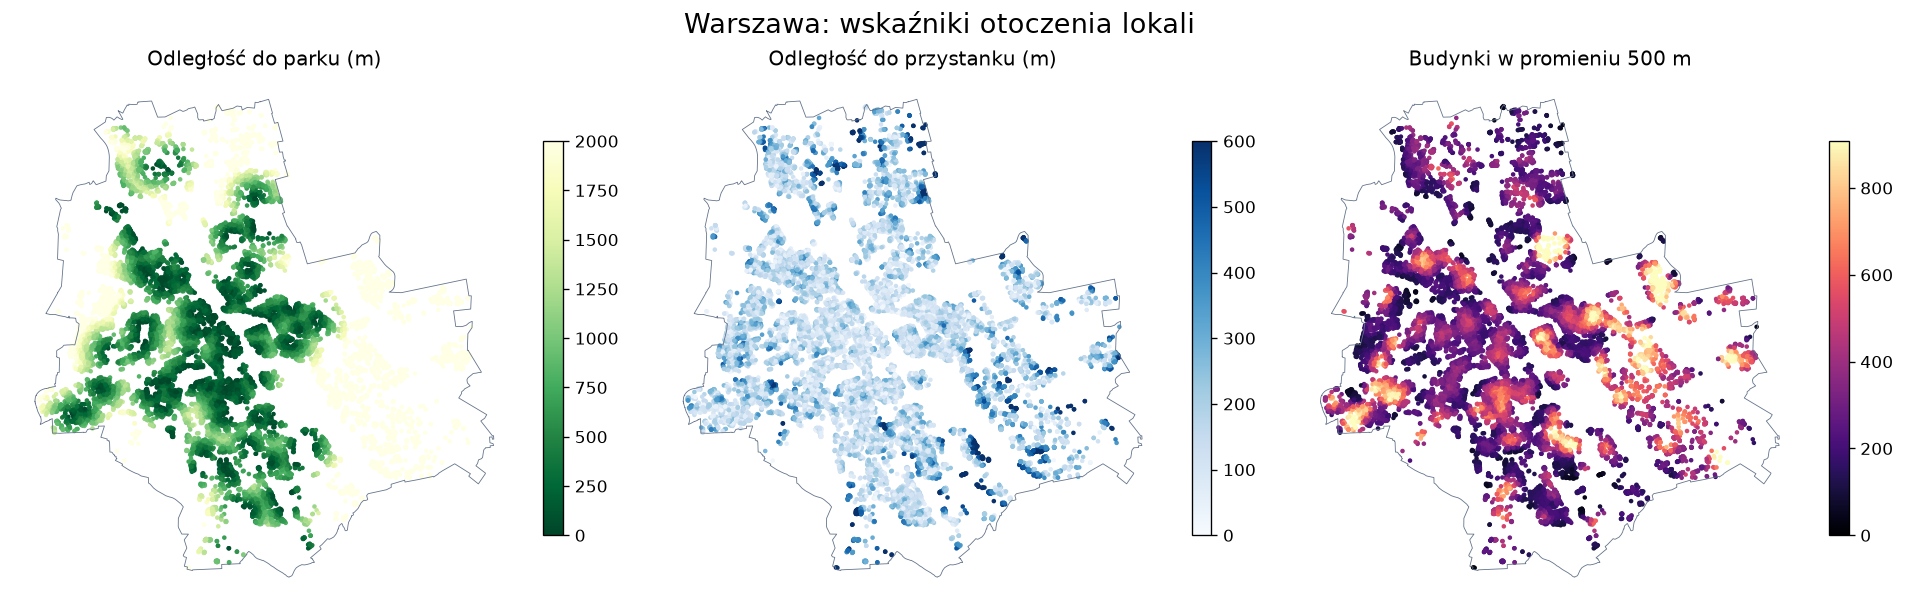

,count,mean,std,min,5%,50%,95%,max,braki,unikalne
bdot_poza_warszawa,20443.0,0.000196,0.013987,0.000000,0.000000,0.000000,0.000000,1.000000,0,2
bdot_dist_granica_m,20443.0,4035.009442,2168.858684,3.086856,602.739160,4005.483618,7527.755447,8481.112445,0,20443
bdot_bufor_100m_uciety,20443.0,0.006017,0.077336,0.000000,0.000000,0.000000,0.000000,1.000000,0,2
bdot_bufor_250m_uciety,20443.0,0.015996,0.125462,0.000000,0.000000,0.000000,0.000000,1.000000,0,2
bdot_bufor_300m_uciety,20443.0,0.019860,0.139523,0.000000,0.000000,0.000000,0.000000,1.000000,0,2
bdot_bufor_500m_uciety,20443.0,0.038399,0.192163,0.000000,0.000000,0.000000,0.000000,1.000000,0,2
bdot_bufor_1000m_uciety,20443.0,0.093773,0.291520,0.000000,0.000000,0.000000,1.000000,1.000000,0,2
bdot_dzielnica_niejednoznaczna,20443.0,0.000196,0.013987,0.000000,0.000000,0.000000,0.000000,1.000000,0,2
bdot_przystanek_dist_m,20439.0,200.253920,143.421003,7.161307,44.972083,164.732507,478.413143,1646.427938,4,20439
bdot_przystanek_n_300m,20439.0,4.092862,3.501469,0.000000,0.000000,4.000000,11.000000,27.000000,4,27


Cechy stałe lub całkowicie puste: []


In [11]:
model_cols=[d['cecha'] for d in feature_definitions if d['rola']=='model']
features.loc[~city_inside,model_cols]=np.nan
fig,axes=plt.subplots(1,3,figsize=(16,5),constrained_layout=True)
map_specs=[('bdot_park_dist_m','Odległość do parku (m)','YlGn_r',2000),
           ('bdot_przystanek_dist_m','Odległość do przystanku (m)','Blues',600),
           ('bdot_budynki_n_500m','Budynki w promieniu 500 m','magma',None)]
for ax,(col,title,cmap,vmax) in zip(axes,map_specs):
    for ring in line_parts(city): ax.plot(ring[:,0],ring[:,1],color='#64748b',linewidth=0.5)
    vals=features[col].to_numpy(dtype=float)
    sc=ax.scatter(x=np.asarray(shapely.get_x(qxy)),y=np.asarray(shapely.get_y(qxy)),c=vals,s=3,cmap=cmap,
                  vmin=0,vmax=vmax if vmax else np.nanquantile(vals,0.98),rasterized=True)
    ax.set_title(title); ax.set_aspect('equal'); ax.set_axis_off()
    fig.colorbar(sc,ax=ax,shrink=0.75)
fig.suptitle('Warszawa: wskaźniki otoczenia lokali',fontsize=16)
fig.savefig(OUT/'mapy_wskaznikow.png',dpi=170,bbox_inches='tight')
plt.show()

numeric=features.select_dtypes(include='number')
summary=numeric.describe(percentiles=[.05,.5,.95]).T
summary['braki']=numeric.isna().sum()
summary['unikalne']=numeric.nunique()
display(summary)
print('Cechy stałe lub całkowicie puste:',list(summary.index[summary.unikalne.le(1)]))

## 11. Eksport i dołączenie do danych modelowych

Eksportujemy zestaw cech dla lokalizacji, pełny zbiór lokali z cechami oraz dokumentację obliczeń. **Wiersze oryginalnego CSV pozostają w tej samej kolejności**, także powtarzające się lokale i rekordy spoza zakresu. Klucz łączenia to para współrzędnych przeliczona numerycznie; relacja jest kontrolowana jako wiele-do-jednego.

`slownik_cech.csv` rozdziela role `model` i `jakosc`. Flagi jakości służą do audytu/dochodzenia do poprawnej próby, a ich użycie w modelu wymaga świadomej decyzji. Nie trenuj modelu na `source_row_id`, `location_id`, sumach kontrolnych ani dacie wersji paczki. Braki udziałów pokrycia przy granicy i braki średniej kondygnacji nie są zerami.

In [12]:
location_features=pd.concat([unique,features],axis=1)
joined_keys=coords.merge(location_features,on=['latitude','longitude'],how='left',sort=False,validate='many_to_one')
assert len(joined_keys)==len(raw)
# Jawne zachowanie kolejności również przy przyszłej zmianie zachowania merge.
keys=coords.copy(); keys['source_row_id']=raw.source_row_id
joined_keys=keys.merge(location_features,on=['latitude','longitude'],how='left',sort=False,validate='many_to_one').sort_values('source_row_id')
assert np.array_equal(joined_keys.source_row_id,raw.source_row_id)
result=pd.concat([raw.reset_index(drop=True),joined_keys[['location_id',*features.columns]].reset_index(drop=True)],axis=1)
result['bdot_wspolrzedne_bledne']=(~valid).astype('int8')
feature_definitions.append({'cecha':'bdot_wspolrzedne_bledne','opis':'Brak lub nieprawidłowy zakres współrzędnych wejściowych',
 'jednostka':'0/1','zrodlo':'warszawa_lokale.csv','metoda':'walidacja zakresu i skończoności','rola':'jakosc'})
assert len(result)==len(raw)
pd.testing.assert_frame_equal(result[raw.columns],raw,check_dtype=True)
assert not result.columns.duplicated().any()
assert set(c for c in result if c.startswith('bdot_'))=={d['cecha'] for d in feature_definitions}
# Brak wyników przestrzennych dla nieprawidłowych współrzędnych.
assert result.loc[~valid,model_cols].isna().all().all()
feature_dictionary=pd.DataFrame(feature_definitions)

def save_csv(df,name):
    path=OUT/name; tmp=path.with_suffix(path.suffix+'.tmp')
    df.to_csv(tmp,index=False,encoding='utf-8')
    tmp.replace(path)

save_csv(inventory,'inwentaryzacja_warstw.csv')
save_csv(attributes,'profil_atrybutow.csv')
save_csv(source_versions,'wersje_obiektow.csv')
save_csv(axis_report,'kontrola_osi.csv')
save_csv(group_catalog,'katalog_grup.csv')
save_csv(pd.DataFrame(selection_audit),'filtry_eksploatacji.csv')
save_csv(feature_dictionary,'slownik_cech.csv')
save_csv(computation_report,'raport_obliczen.csv')
save_csv(censor_report,'ryzyko_granicy_odleglosci.csv')
save_csv(accuracy_report,'kontrola_dokladnosci.csv')
save_csv(summary.reset_index(names='cecha'),'statystyki_cech.csv')
save_csv(location_features,'wskazniki_lokalizacje.csv')
save_csv(result,'warszawa_lokale_bdot10k.csv')
# Pełna kontrola zachowania kolumn wejściowych także po serializacji.
roundtrip=pd.read_csv(OUT/'warszawa_lokale_bdot10k.csv',usecols=raw.columns.tolist(),float_precision='round_trip')
pd.testing.assert_frame_equal(roundtrip[raw.columns],raw)
# Ponowny odczyt wybranych kolumn eksportu: liczba wierszy, kolejność, spójność flag.
check=pd.read_csv(OUT/'warszawa_lokale_bdot10k.csv',float_precision='round_trip',usecols=['source_row_id','bdot_wspolrzedne_bledne','bdot_park_dist_m'])
assert len(check)==len(raw) and np.array_equal(check.source_row_id,raw.source_row_id)
assert np.allclose(check.bdot_park_dist_m,result.bdot_park_dist_m,equal_nan=True,atol=1e-6)

manifest={'czas_utc':datetime.now(timezone.utc).isoformat(),'python':platform.python_version(),'biblioteki':versions,
 'wejscia':input_manifest+[{'plik':str(INPUT.relative_to(ROOT)),'bytes':INPUT.stat().st_size,'sha256':sha256(INPUT)}],
 'parametry':{'promien_ziemi_m':EARTH_R_M,'krok_probkowania_granic_m':BOUNDARY_STEP_M,
              'udzial_pokrycia_probki':AREA_N,'udzial_pokrycia_promien_m':AREA_RADIUS_M,
              'filtr_statusu':'eksploatowany; zachowaj gdy klasa nie ma pola',
              'metryka':'Haversine','wersja_definicji_cech':'1.0'},
 'rekordy_lokali':len(raw),'unikalne_lokalizacje':len(unique),'liczba_cech':len(feature_dictionary),
 'cechy_modelowe':model_cols,'cechy_jakosciowe':feature_dictionary.loc[feature_dictionary.rola.eq('jakosc'),'cecha'].tolist(),
 'obiekty_gml':int(inventory.obiekty.sum()),
 'jakosc':{'lokalizacje_poza_warszawa':int((~city_inside).sum()),'lokalizacje_bufor_1000m_uciety':int(features.bdot_bufor_1000m_uciety.sum()),'rekordy_bledne_wspolrzedne':int((~valid).sum())},'sekundy':round(time.perf_counter()-STARTED,2),
 'ograniczenie_czasowe':'Przekrój BDOT10k; wersja obiektu nie jest datą powstania/otwarcia; brak rekonstrukcji historycznej.'}
manifest['wyjscia']=[{'plik':p.name,'bytes':p.stat().st_size,'sha256':sha256(p)} for p in sorted(OUT.iterdir()) if p.suffix in ['.csv','.png']]
(OUT/'manifest.json').write_text(json.dumps(manifest,ensure_ascii=False,indent=2),encoding='utf-8')
display(pd.DataFrame(manifest['wyjscia'])[['plik','bytes']])
print(f'Zapisano {len(result):,} rekordów, {len(unique):,} lokalizacji, {len(feature_dictionary)} cech (model: {len(model_cols)}).')
print(f'Czas wykonania: {manifest["sekundy"]:.1f} s')

,plik,bytes
0,filtry_eksploatacji.csv,530
1,inwentaryzacja_warstw.csv,14080
2,katalog_grup.csv,4317
3,kontrola_dokladnosci.csv,278
4,kontrola_osi.csv,2230
5,mapy_wskaznikow.png,898316
6,profil_atrybutow.csv,132300
7,raport_obliczen.csv,1587
8,ryzyko_granicy_odleglosci.csv,1063
9,slownik_cech.csv,13488


Zapisano 229,727 rekordów, 20,443 lokalizacji, 88 cech (model: 78).
Czas wykonania: 126.0 s


## 12. Wnioski i dalsza walidacja

**Paczka daje podstawy do opisania dostępności usług, zieleni i transportu oraz charakteru zabudowy.** Poszczególne wskaźniki mają odrębne jednostki obserwacji: punkty przystanków, wejścia do metra, budynki, kompleksy albo fragmenty pokrycia terenu. Słownik cech dokumentuje tę różnicę.

Najważniejsze ograniczenia interpretacyjne:

1. **Czas:** `wersja`/`poczatekWersjiObiektu` opisują wersję rekordu, nie rok budowy ani datę otwarcia. Cechy reprezentują stan paczki z wersjami widocznymi w sekcji 1. Przypisanie ich transakcjom z 2016 r. może wprowadzić informację z przyszłości. Filtrowanie `wersja <= data transakcji` nie naprawiłoby problemu. Do badania historycznego potrzebne są archiwalne stany albo jawnie zawężony/oznaczony eksperyment.
2. **Zasięg:** obiekty za granicą Warszawy są nieobserwowane. Flagi graniczne są istotne zwłaszcza w dzielnicach peryferyjnych. Docelowo należy dodać paczki sąsiednich powiatów z buforem większym niż największy analizowany promień.
3. **Dostępność:** odległość w linii prostej nie uwzględnia rzeki, ogrodzeń, wejść do parku, przepraw czy rozkładów jazdy. Bliskość toru opisuje inne zjawisko niż bliskość przystanku.
4. **Kompletność:** BDOT10k nie jest pełnym rejestrem sklepów, instytucji, drzew ani lokali usługowych. Kilka punktów tego samego zespołu przystankowego nie oznacza kilku niezależnych linii transportowych.
5. **Dokładność:** geokodowanie lokali, generalizacja mapy, naprawa geometrii, próbkowanie granic oraz udziałów powierzchni wpływają na wyniki. Testy algorytmów nie eliminują błędów źródła.

**Proponowany eksperyment:** porównać identyczny model i identyczne podziały danych dla cech podstawowych, następnie dodać grupami transport, usługi, zieleń, uciążliwości i zabudowę. Zachować rozdział czasowy oraz grupowanie po budynku/lokalu, dodać test przestrzenny. Dobór promieni i eliminację silnie skorelowanych cech przeprowadzać tylko na zbiorze treningowym. Raportować MAE i błędy względne również według dzielnic, segmentów cenowych oraz flag granicznych. Dopiero to pozwoli ocenić, które wskaźniki rzeczywiście poprawiają predykcję.